In [ ]:
import asyncio
from playwright.async_api import async_playwright
import pandas as pd
import json
import os
import time
import nest_asyncio

nest_asyncio.apply()

# ============================================================
# CONFIGURATION
# ============================================================

BASE_URL = "https://syarah.com/en/filters?condition_id=0"
OUTPUT_FILE = "syarah_used_cars.csv"
START_PAGE = 1
MAX_PAGES = None  # Scrape all pages
WAIT_BETWEEN_PAGES = 5.0 # Increased wait to be safer
CARS_PER_PAGE = 16

# ============================================================
# DATA PROCESSING
# ============================================================

def flatten_car(car):
    row = {}
    row["id"] = car.get("id")
    row["uniqueId"] = car.get("uniqueId")
    g4 = car.get("g4_data_layer", {})
    row["make"] = g4.get("post_make")
    row["model"] = g4.get("post_model")
    row["year"] = car.get("year")
    row["price"] = g4.get("post_price")
    row["sellingprice"] = car.get("sellingprice")
    row["mileage"] = g4.get("post_mileage")
    row["city_name"] = car.get("city_name")
    row["transmission"] = g4.get("post_transmission")
    row["fuel"] = g4.get("post_fuel")
    row["product_url"] = car.get("product_url")
    return row

def save_data(rows):
    if not rows: return
    df = pd.DataFrame(rows)
    if "id" in df.columns:
        df.drop_duplicates(subset=["id"], inplace=True)
    df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")

# ============================================================
# MAIN SCRAPER
# ============================================================

async def main():
    all_rows = []
    if os.path.exists(OUTPUT_FILE):
        try:
            existing_df = pd.read_csv(OUTPUT_FILE)
            all_rows.extend(existing_df.to_dict(orient='records'))
            print(f"Loaded {len(all_rows)} existing records.")
        except Exception: pass

    # Resume logic
    current_page = (len(all_rows) // CARS_PER_PAGE) + 1 if all_rows else START_PAGE

    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context(viewport={"width": 1280, "height": 800})
        page = await context.new_page()

        total_pages = 999

        async def handle_response(response):
            nonlocal total_pages
            if "/api/syarah_v1/en/search/index" in response.url and response.status == 200:
                try:
                    payload = await response.json()
                    data_part = payload.get("data", {})
                    products = data_part.get("products", [])
                    total_pages = data_part.get("total_pages", total_pages)

                    if products:
                        print(f"Captured {len(products)} cars from API (Total Pages: {total_pages})")
                        for car in products:
                            all_rows.append(flatten_car(car))
                        save_data(all_rows)
                except Exception as e:
                    print(f"Error parsing API: {e}")

        page.on("response", handle_response)

        page_num = current_page
        while page_num <= total_pages:
            if MAX_PAGES and page_num > MAX_PAGES: break

            # Using the exact URL format that worked previously
            target_url = f"{BASE_URL}&page={page_num}"
            print(f"\n--- Opening Page {page_num} of {total_pages} ---")

            try:
                await page.goto(target_url, wait_until="domcontentloaded", timeout=90000)
                # Wait for the JS and API to finish as in the working version
                await page.wait_for_timeout(5000)
                await asyncio.sleep(WAIT_BETWEEN_PAGES)
            except Exception as e:
                print(f"Timeout/Error on page {page_num}: {type(e).__name__}. Retrying next loop...")
                await asyncio.sleep(10)
                continue

            page_num += 1

        await browser.close()
        print(f"\nScraping complete. Total cars saved: {len(all_rows)}")

if __name__ == "__main__":
    asyncio.run(main())

Loaded 80 existing records.

--- Opening Page 6 of 999 ---

--- Opening Page 7 of 999 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 8 of 190 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 9 of 190 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 10 of 190 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 11 of 190 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 12 of 190 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 13 of 190 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 14 of 190 ---
Captured 16 c

In [ ]:
import asyncio
from playwright.async_api import async_playwright
import pandas as pd
import json
import os
import time
import nest_asyncio

nest_asyncio.apply()

# ============================================================
# CONFIGURATION
# ============================================================

BASE_URL = "https://syarah.com/en/filters?condition_id=0"
OUTPUT_FILE = "syarah_used_cars.csv"
START_PAGE = 1
MAX_PAGES = None  # Scrape all pages
WAIT_BETWEEN_PAGES = 5.0 # Increased wait to be safer
CARS_PER_PAGE = 16

# ============================================================
# DATA PROCESSING
# ============================================================

def flatten_car(car):
    row = {}
    row["id"] = car.get("id")
    row["uniqueId"] = car.get("uniqueId")
    g4 = car.get("g4_data_layer", {})
    row["make"] = g4.get("post_make")
    row["model"] = g4.get("post_model")
    row["year"] = car.get("year")
    row["price"] = g4.get("post_price")
    row["sellingprice"] = car.get("sellingprice")
    row["mileage"] = g4.get("post_mileage")
    row["city_name"] = car.get("city_name")
    row["transmission"] = g4.get("post_transmission")
    row["fuel"] = g4.get("post_fuel")
    row["product_url"] = car.get("product_url")
    return row

def save_data(rows):
    if not rows: return
    df = pd.DataFrame(rows)
    if "id" in df.columns:
        df.drop_duplicates(subset=["id"], inplace=True)
    df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")

# ============================================================
# MAIN SCRAPER
# ============================================================

async def main():
    all_rows = []
    if os.path.exists(OUTPUT_FILE):
        try:
            existing_df = pd.read_csv(OUTPUT_FILE)
            all_rows.extend(existing_df.to_dict(orient='records'))
            print(f"Loaded {len(all_rows)} existing records.")
        except Exception: pass

    # Resume logic
    current_page = (len(all_rows) // CARS_PER_PAGE) + 1 if all_rows else START_PAGE

    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context(viewport={"width": 1280, "height": 800})
        page = await context.new_page()

        total_pages = 999

        async def handle_response(response):
            nonlocal total_pages
            if "/api/syarah_v1/en/search/index" in response.url and response.status == 200:
                try:
                    payload = await response.json()
                    data_part = payload.get("data", {})
                    products = data_part.get("products", [])
                    total_pages = data_part.get("total_pages", total_pages)

                    if products:
                        print(f"Captured {len(products)} cars from API (Total Pages: {total_pages})")
                        for car in products:
                            all_rows.append(flatten_car(car))
                        save_data(all_rows)
                except Exception as e:
                    print(f"Error parsing API: {e}")

        page.on("response", handle_response)

        page_num = current_page
        while page_num <= total_pages:
            if MAX_PAGES and page_num > MAX_PAGES: break

            # Using the exact URL format that worked previously
            target_url = f"{BASE_URL}&page={page_num}"
            print(f"\n--- Opening Page {page_num} of {total_pages} ---")

            try:
                await page.goto(target_url, wait_until="domcontentloaded", timeout=90000)
                # Wait for the JS and API to finish as in the working version
                await page.wait_for_timeout(5000)
                await asyncio.sleep(WAIT_BETWEEN_PAGES)
            except Exception as e:
                print(f"Timeout/Error on page {page_num}: {type(e).__name__}. Retrying next loop...")
                await asyncio.sleep(10)
                continue

            page_num += 1

        await browser.close()
        print(f"\nScraping complete. Total cars saved: {len(all_rows)}")

if __name__ == "__main__":
    asyncio.run(main())

Loaded 80 existing records.

--- Opening Page 6 of 999 ---

--- Opening Page 7 of 999 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 8 of 190 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 9 of 190 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 10 of 190 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 11 of 190 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 12 of 190 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 13 of 190 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 14 of 190 ---
Captured 16 c

In [1]:
"""
Vehicle market-value scraper — used-car listings.
CrashLens · builds the vehicle valuation lookup used by the referral gate.

WHY THIS EXISTS
    The cost-estimation referral gate needs the market value of a *used*
    vehicle (make/model/year) to compute the repair-to-value ratio. New-car
    manufacturer sites (Lexus/Toyota) list showroom prices, which are NOT
    used-vehicle values, so only a used-car source is scraped here.

DESIGN
    This script does ONE thing: fetch raw listings and save them to JSON.
    It does NOT aggregate and does NOT touch Firebase — those are separate
    steps (aggregate_values.py, upload_to_firebase.py) so each can be run and
    inspected independently. Scrape, look at what you got, THEN aggregate and
    upload.

    Output granularity is individual listings. Aggregation to
    (model, year) -> median value happens in the next step.

BEFORE YOU RUN
    1. This has NOT been tested against the live site — no network access in
       the dev environment where it was written. HTML selectors (marked
       # VERIFY) almost certainly need adjusting once you see real pages.
    2. It checks robots.txt and refuses to scrape disallowed paths. Do not
       remove that check.
    3. It rate-limits to one request every few seconds. Do not lower this to
       "go faster" — it is both courteous and what keeps your IP unblocked.

    Install:  pip install requests beautifulsoup4
"""
!pip install requests beautifulsoup4
import json
import time
import random
import urllib.robotparser
from urllib.parse import urljoin, urlparse
from datetime import datetime

import requests
from bs4 import BeautifulSoup


# ─────────────────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────────────────
BASE_URL = "https://www.salehcars.com"
LISTINGS_PATH = "/cars/all"

# Politeness settings — do not make these more aggressive.
MIN_DELAY_SECONDS = 3.0          # minimum wait between requests
MAX_DELAY_SECONDS = 6.0          # jitter avoids a robotic fixed interval
REQUEST_TIMEOUT = 20
MAX_PAGES = 50                   # safety cap so a bug can't loop forever

USER_AGENT = (
    "CrashLens-AcademicResearch/1.0 "
    "(King Saud University graduation project; contact: your-email@example.com)"
)

OUTPUT_FILE = "vehicle_listings_raw.json"


# ─────────────────────────────────────────────────────────────────────
# robots.txt gate — refuse to proceed if scraping is disallowed
# ─────────────────────────────────────────────────────────────────────
def check_robots_permission(url: str) -> bool:
    robots_url = urljoin(BASE_URL, "/robots.txt")
    rp = urllib.robotparser.RobotFileParser()
    rp.set_url(robots_url)
    try:
        rp.read()
    except Exception as e:
        # If robots.txt cannot be read, the safe default is to STOP and let a
        # human decide, not to assume permission.
        print(f"⚠️  Could not read {robots_url}: {e}")
        print("    Stopping. Verify the site's policy manually before scraping.")
        return False

    allowed = rp.can_fetch(USER_AGENT, url)
    if not allowed:
        print(f"🚫 robots.txt DISALLOWS scraping {url}")
        print("    Do not proceed. Consider contacting the site for permission,")
        print("    or use a source that permits research scraping.")
    else:
        print(f"✅ robots.txt allows {url}")
    return allowed


def polite_delay():
    time.sleep(random.uniform(MIN_DELAY_SECONDS, MAX_DELAY_SECONDS))


# ─────────────────────────────────────────────────────────────────────
# Fetch one page
# ─────────────────────────────────────────────────────────────────────
def fetch_page(url: str, session: requests.Session):
    try:
        resp = session.get(url, timeout=REQUEST_TIMEOUT)
        if resp.status_code == 200:
            return resp.text
        print(f"   ⚠️  {url} returned {resp.status_code}")
        return None
    except requests.RequestException as e:
        print(f"   ❌ Request failed for {url}: {e}")
        return None


# ─────────────────────────────────────────────────────────────────────
# Parse listings from one page
#
# ⚠️ EVERYTHING IN THIS FUNCTION IS A GUESS until you inspect real HTML.
# The class names below are placeholders. To find the real ones:
#   1. Open the site, right-click a listing → Inspect.
#   2. Find the repeating container element and its class.
#   3. Replace the selectors marked # VERIFY.
# The site may also load listings via JavaScript/JSON — see the note at the
# bottom of this file if parsing returns nothing.
# ─────────────────────────────────────────────────────────────────────
def parse_listings(html: str) -> list:
    soup = BeautifulSoup(html, "html.parser")
    listings = []

    cards = soup.select("div.car-card")                    # VERIFY
    print(f"   Found {len(cards)} listing containers on page")

    for card in cards:
        try:
            model_el = card.select_one(".car-title")       # VERIFY
            price_el = card.select_one(".car-price")        # VERIFY
            year_el = card.select_one(".car-year")          # VERIFY

            raw_model = model_el.get_text(strip=True) if model_el else ""
            raw_price = price_el.get_text(strip=True) if price_el else ""
            raw_year = year_el.get_text(strip=True) if year_el else ""

            price = _parse_price(raw_price)
            year = _parse_year(raw_year)

            # Skip a listing missing anything the lookup key needs.
            if not raw_model or price is None or year is None:
                continue

            listings.append({
                "raw_model_text": raw_model,   # cleaned later, kept for audit
                "year": year,
                "price_sar": price,
                "source": "salehcars",
                "scraped_at": datetime.utcnow().isoformat(),
            })
        except Exception as e:
            print(f"   ⚠️  Skipped a card: {e}")
            continue

    return listings


def _parse_price(text: str):
    """Extract an integer SAR price from arbitrary text, handling Arabic digits."""
    if not text:
        return None
    arabic = "٠١٢٣٤٥٦٧٨٩"
    text = text.translate(str.maketrans(arabic, "0123456789"))
    digits = "".join(ch for ch in text if ch.isdigit())
    if not digits:
        return None
    value = int(digits)
    # Sanity band — drop monthly-installment figures and obvious noise.
    if value < 5000 or value > 5_000_000:
        return None
    return value


def _parse_year(text: str):
    if not text:
        return None
    arabic = "٠١٢٣٤٥٦٧٨٩"
    text = text.translate(str.maketrans(arabic, "0123456789"))
    digits = "".join(ch for ch in text if ch.isdigit())
    for i in range(len(digits) - 3):
        candidate = int(digits[i:i + 4])
        if 1990 <= candidate <= datetime.now().year + 1:
            return candidate
    return None


def find_next_page(html: str, current_url: str):
    """Return the next page URL, or None. Selector needs verification."""
    soup = BeautifulSoup(html, "html.parser")
    next_link = soup.select_one("a.next, a[rel='next']")   # VERIFY
    if next_link and next_link.get("href"):
        return urljoin(current_url, next_link["href"])
    return None


# ─────────────────────────────────────────────────────────────────────
# Main scrape loop
# ─────────────────────────────────────────────────────────────────────
def scrape():
    start_url = urljoin(BASE_URL, LISTINGS_PATH)

    if not check_robots_permission(start_url):
        return

    session = requests.Session()
    session.headers.update({"User-Agent": USER_AGENT})

    all_listings = []
    url = start_url
    page_num = 1

    while url and page_num <= MAX_PAGES:
        print(f"\n📄 Page {page_num}: {url}")
        html = fetch_page(url, session)
        if html is None:
            break

        page_listings = parse_listings(html)
        all_listings.extend(page_listings)
        print(f"   Collected {len(page_listings)} (total {len(all_listings)})")

        next_url = find_next_page(html, url)
        # Guard against a self-referencing 'next' link looping forever.
        if next_url == url:
            break
        url = next_url
        page_num += 1

        if url:
            polite_delay()

    with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
        json.dump(all_listings, f, ensure_ascii=False, indent=2)

    print(f"\n✅ Done. {len(all_listings)} listings → {OUTPUT_FILE}")
    if not all_listings:
        print("\n⚠️  ZERO listings collected. Most likely one of:")
        print("   • The # VERIFY selectors don't match the real HTML.")
        print("   • Listings are loaded by JavaScript (see note below).")


if __name__ == "__main__":
    scrape()


# ─────────────────────────────────────────────────────────────────────
# IF YOU GET ZERO LISTINGS
#
# Many modern car sites render listings client-side with JavaScript, so the
# HTML `requests` receives is nearly empty. Two ways to tell:
#
#   • Save the HTML and search it for a known price. If absent, it's JS-loaded.
#   • Open the site with browser DevTools → Network → XHR. If you see a request
#     returning JSON full of listings, that JSON endpoint is far better than
#     scraping HTML — hit it directly with requests and parse JSON. This is
#     both easier and more stable than HTML parsing.
#
# Only if neither works do you need a browser-automation tool (Selenium /
# Playwright). Try the JSON-endpoint route first.
# ─────────────────────────────────────────────────────────────────────

✅ robots.txt allows https://www.salehcars.com/cars/all

📄 Page 1: https://www.salehcars.com/cars/all
   Found 0 listing containers on page
   Collected 0 (total 0)

✅ Done. 0 listings → vehicle_listings_raw.json

⚠️  ZERO listings collected. Most likely one of:
   • The # VERIFY selectors don't match the real HTML.
   • Listings are loaded by JavaScript (see note below).


In [1]:
!pip install requests
"""
Vehicle price scraper — looks up each car by its ID.
CrashLens · fetches price/model/year for a known list of car IDs.

INPUT:  car_ids.txt  — one car ID per line (extracted from the URLs you
                       already collected). A helper below can also pull IDs
                       straight out of pasted salehcars URLs.
OUTPUT: vehicle_listings_raw.json — same format the aggregate step expects.

STRATEGY (per car, in order):
    1. Try the JSON API detail endpoint. Clean, structured, preferred.
    2. If that fails, fetch the car's normal web page and dig the price out
       of the embedded data. Next.js pages embed their data as JSON in the
       HTML, so this usually still works without parsing visible markup.

The API base and detail path are best guesses from the URLs seen so far and
are marked # VERIFY. If step 1 returns nothing for every car, open ONE working
API request in DevTools, read its real path, and correct API_DETAIL_TEMPLATE —
then every ID works.

    pip install requests
"""

import json
import re
import time
import random
import sys

import requests

# ─────────────────────────────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────────────────────────────
API_BASE = "https://api.v1.salehcars.com/v1/public"

# The brands endpoint you confirmed is:  {API_BASE}/models/Brand
# A single car is almost certainly one of these shapes. The scraper tries
# each in order and remembers the first that works, so you don't have to know
# which is right up front.
API_DETAIL_CANDIDATES = [                      # VERIFY (auto-detected at runtime)
    API_BASE + "/cars/{id}",
    API_BASE + "/car/{id}",
    API_BASE + "/models/car/{id}",
    API_BASE + "/models/{id}",
    API_BASE + "/vehicles/{id}",
]

CAR_PAGE_TEMPLATE = "https://www.salehcars.com/cars/{id}"   # HTML fallback

IDS_FILE = "car_ids.txt"
OUTPUT_FILE = "vehicle_listings_raw.json"

MIN_DELAY, MAX_DELAY = 1.5, 3.0
TIMEOUT = 20
USER_AGENT = (
    "CrashLens-AcademicResearch/1.0 "
    "(King Saud University graduation project; contact: your-email@example.com)"
)


def delay():
    time.sleep(random.uniform(MIN_DELAY, MAX_DELAY))


# ─────────────────────────────────────────────────────────────────────
# Pull car IDs out of pasted URLs (24-char hex Mongo-style IDs)
# ─────────────────────────────────────────────────────────────────────
def extract_ids_from_text(text: str) -> list:
    ids = re.findall(r"/cars/([a-f0-9]{24})", text)
    seen, out = set(), []
    for i in ids:
        if i not in seen:
            seen.add(i)
            out.append(i)
    return out


def load_ids() -> list:
    """
    Reads car_ids.txt. Accepts either bare IDs (one per line) or full pasted
    URLs — it extracts the ID from each either way.
    """
    try:
        with open(IDS_FILE, encoding="utf-8") as f:
            raw = f.read()
    except FileNotFoundError:
        print(f"❌ {IDS_FILE} not found. Create it with one car ID or URL per line.")
        sys.exit(1)

    ids = []
    for line in raw.splitlines():
        line = line.strip()
        if not line:
            continue
        found = extract_ids_from_text(line)
        if found:
            ids.extend(found)
        elif re.fullmatch(r"[a-f0-9]{24}", line):
            ids.append(line)

    # de-dup, keep order
    seen, out = set(), []
    for i in ids:
        if i not in seen:
            seen.add(i)
            out.append(i)
    return out


# ─────────────────────────────────────────────────────────────────────
# Field extraction — the API may name fields differently than we guess,
# so search common key names rather than assuming one.
# ─────────────────────────────────────────────────────────────────────
def _pick(d: dict, *keys):
    for k in keys:
        if k in d and d[k] not in (None, "", []):
            return d[k]
    return None


def _extract_from_obj(obj: dict) -> dict | None:
    """Pull model/year/price out of a car object regardless of exact schema."""
    if not isinstance(obj, dict):
        return None

    # Some APIs wrap the car under 'result' / 'data'.
    for wrapper in ("result", "data", "car", "vehicle"):
        if wrapper in obj and isinstance(obj[wrapper], dict):
            obj = obj[wrapper]
            break

    price = _pick(obj, "price", "sellPrice", "sellingPrice", "amount", "cashPrice")
    year = _pick(obj, "year", "modelYear", "manufactureYear", "makeYear")

    # model / name may be a plain string or an {en, ar} object
    model = _pick(obj, "model", "name", "title", "modelName")
    if isinstance(model, dict):
        model = model.get("ar") or model.get("en")

    brand = _pick(obj, "brand", "make", "manufacturer")
    if isinstance(brand, dict):
        brand = brand.get("ar") or brand.get("en")

    def to_int(x):
        if x is None:
            return None
        digits = "".join(ch for ch in str(x) if ch.isdigit())
        return int(digits) if digits else None

    price = to_int(price)
    year = to_int(year)

    if price is None or not (5000 <= price <= 5_000_000):
        price = None
    if year is not None and not (1990 <= year <= 2027):
        year = None

    if model and price:
        return {
            "raw_model_text": f"{brand or ''} {model}".strip(),
            "year": year,
            "price_sar": price,
            "source": "salehcars",
        }
    return None


# ─────────────────────────────────────────────────────────────────────
# Attempt 1: JSON API
# ─────────────────────────────────────────────────────────────────────
_working_template = {"value": None}   # cache the endpoint that works


def try_api(car_id: str, session: requests.Session) -> dict | None:
    templates = ([_working_template["value"]] if _working_template["value"]
                 else API_DETAIL_CANDIDATES)
    for tmpl in templates:
        if tmpl is None:
            continue
        url = tmpl.format(id=car_id)
        try:
            resp = session.get(url, timeout=TIMEOUT)
            if resp.status_code == 200 and resp.text.strip().startswith(("{", "[")):
                data = resp.json()
                rec = _extract_from_obj(data if isinstance(data, dict) else {})
                if rec:
                    _working_template["value"] = tmpl   # remember for next cars
                    return rec
        except (requests.RequestException, ValueError):
            continue
    return None


# ─────────────────────────────────────────────────────────────────────
# Attempt 2: HTML page — dig the embedded JSON out of a Next.js page
# ─────────────────────────────────────────────────────────────────────
def try_html(car_id: str, session: requests.Session) -> dict | None:
    url = CAR_PAGE_TEMPLATE.format(id=car_id)
    try:
        resp = session.get(url, timeout=TIMEOUT)
    except requests.RequestException:
        return None
    if resp.status_code != 200:
        return None

    html = resp.text

    # Next.js embeds page data in a __NEXT_DATA__ script tag as JSON.
    m = re.search(
        r'<script id="__NEXT_DATA__"[^>]*>(.*?)</script>', html, re.DOTALL)
    if m:
        try:
            blob = json.loads(m.group(1))
            found = _deep_find_car(blob)
            if found:
                return found
        except ValueError:
            pass

    # Last resort: find a price-like number near a currency marker.
    m = re.search(r'(\d[\d,]{3,})\s*(?:ريال|SAR|ر\.س)', html)
    if m:
        price = int(m.group(1).replace(",", ""))
        ytext = re.search(r'\b(20[0-2]\d)\b', html)
        if 5000 <= price <= 5_000_000:
            return {
                "raw_model_text": f"car_{car_id}",   # name unknown from HTML
                "year": int(ytext.group(1)) if ytext else None,
                "price_sar": price,
                "source": "salehcars",
            }
    return None


def _deep_find_car(obj) -> dict | None:
    """Recursively search embedded JSON for an object that looks like a car."""
    if isinstance(obj, dict):
        rec = _extract_from_obj(obj)
        if rec:
            return rec
        for v in obj.values():
            found = _deep_find_car(v)
            if found:
                return found
    elif isinstance(obj, list):
        for v in obj:
            found = _deep_find_car(v)
            if found:
                return found
    return None


# ─────────────────────────────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────────────────────────────
def main():
    ids = load_ids()
    print(f"Loaded {len(ids)} car IDs")
    if not ids:
        return

    session = requests.Session()
    session.headers.update({
        "User-Agent": USER_AGENT,
        "Accept": "application/json, text/html",
    })

    results, api_hits, html_hits, misses = [], 0, 0, 0

    for idx, car_id in enumerate(ids, 1):
        rec = try_api(car_id, session)
        if rec:
            api_hits += 1
        else:
            rec = try_html(car_id, session)
            if rec:
                html_hits += 1

        if rec:
            rec["car_id"] = car_id
            results.append(rec)
            print(f"  [{idx}/{len(ids)}] ✅ {rec['raw_model_text']} "
                  f"{rec.get('year') or '?'} — {rec['price_sar']} SAR")
        else:
            misses += 1
            print(f"  [{idx}/{len(ids)}] ⚠️  no price for {car_id}")

        delay()

    with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)

    print(f"\n✅ {len(results)} cars saved → {OUTPUT_FILE}")
    print(f"   via API: {api_hits} · via HTML: {html_hits} · missed: {misses}")
    if _working_template["value"]:
        print(f"   Working API endpoint: {_working_template['value']}")
    if not results:
        print("\n⚠️  Nothing worked. Open ONE car's API request in DevTools,")
        print("    read its real path, and set it as the first entry in")
        print("    API_DETAIL_CANDIDATES. Then re-run — all IDs will resolve.")


if __name__ == "__main__":
    main()

Loaded 8 car IDs
  [1/8] ⚠️  no price for 66dbf782fd36b93f77fe21b0
  [2/8] ⚠️  no price for 66d9c824c57b1c5a3ab55dab
  [3/8] ⚠️  no price for 66c6fd5cd4c1cfef85e4a128
  [4/8] ⚠️  no price for 66cedaeefb2267354d4c2c3a
  [5/8] ⚠️  no price for 66cee3b7fb2267354d4c7205
  [6/8] ⚠️  no price for 66d07dfa8ad3cb8ce28fd720
  [7/8] ⚠️  no price for 675af0c60d858e879bdefb12
  [8/8] ⚠️  no price for 66d4385f9c229134c94860ba

✅ 0 cars saved → vehicle_listings_raw.json
   via API: 0 · via HTML: 0 · missed: 8

⚠️  Nothing worked. Open ONE car's API request in DevTools,
    read its real path, and set it as the first entry in
    API_DETAIL_CANDIDATES. Then re-run — all IDs will resolve.


In [5]:
"""
Vehicle price scraper — Saleh Cars public API.
CrashLens · builds the vehicle valuation lookup used by the referral gate.

WHAT CHANGED (v1 -> v2 -> v3)
    v1 parsed rendered HTML. It got zero rows: salehcars.com is a client-
    rendered Next.js app, so the served HTML has no listings/prices.
    v3 (this file) talks to the site's real backend API instead — discovered
    from the browser network log:

        https://api.v1.salehcars.com/v1/public/models/{Entity}?page=0&pageSize=500

    Every response is shaped { "total": N, "results": [ ... ] }. Confirmed
    against the Brand entity (52 brands). "Car" is the same pattern.

TWO FINDINGS YOU NEED TO KNOW (evidence, not assumptions):
    1. PRICE IS OFTEN ABSENT. A sample car (GAC GS3 2025) showed
       "متوفر عند الطلب" (available on request) with NO price — a customer had
       even commented asking for it. So expect the price field to be empty for
       many cars. This script counts how many rows actually had a price and
       reports the yield, so you can see how usable this source really is.
    2. THIS IS A NEW-CAR DEALER. Cars are sold "on order" / via financing.
       The v1 WHY note said we need USED-vehicle values and explicitly NOT
       new-car showroom prices. Saleh Cars is the new-car case. Whether it's
       the right source for a repair-to-value ratio is a team decision — this
       script does not assume it is.

PRESERVED — intentional choices from earlier versions, do not "clean up":
    • robots.txt gate that refuses to run on disallowed paths.
    • 3–6 s randomised delay between requests. Do not lower it.
    • Does ONE thing: fetch -> JSON file. No aggregation, no Firebase here.
    • Output granularity = individual records; (model, year) -> median value
      happens in the next step (aggregate_values.py).
    • Arabic-digit + sanity-band price parsing (drops instalment noise).

STILL UNCONFIRMED (one field name):
    The exact PRICE field name inside a Car record. This script auto-detects it
    from a candidate list; if it can't, it prints the record's keys and writes
    sample_car_record.json so you can read the field off (or paste it to me).
    Once known, set PRICE_FIELD_OVERRIDE and it's locked in.

    Install:  pip install requests
"""
# In a notebook, un-comment:

!pip install requests

import json
import time
import random
import urllib.robotparser
from urllib.parse import urlparse
from datetime import datetime

import requests


# ─────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────
API_BASE   = "https://api.v1.salehcars.com/v1/public/models"
ENTITY     = "Car"          # VERIFY: Brand is confirmed; Car is the expected twin.
PAGE_SIZE  = 100            # API accepts large pages (Brand used pageSize=500).
START_PAGE = 0              # Confirmed: this API is 0-indexed.

# --- Field mapping inside a Car record (dotted paths supported) ------
F_ID        = "id"
F_NAME      = "name"        # confirmed shape on Brand: {"en": "...", "ar": "..."}
NAME_LANG   = "en"          # prefer English model text; fall back to Arabic
F_YEAR      = "year"        # VERIFY: may be "modelYear" or absent (we also parse it from the name)

# Price: the record field is unconfirmed. The script tries these in order.
# If you learn the real one, set PRICE_FIELD_OVERRIDE and it wins.
PRICE_FIELD_OVERRIDE   = ""
PRICE_FIELD_CANDIDATES = [
    "price", "cashPrice", "sellPrice", "salePrice", "finalPrice",
    "priceAfterTax", "priceAfterVat", "priceWithTax", "amount", "cash",
]

# --- Politeness — PRESERVED, do not make more aggressive -------------
MIN_DELAY_SECONDS = 3.0
MAX_DELAY_SECONDS = 6.0
REQUEST_TIMEOUT   = 20
MAX_PAGES         = 50       # safety cap so a bug can't loop forever

USER_AGENT = (
    "CrashLens-AcademicResearch/1.0 "
    "(King Saud University graduation project; contact: your-email@example.com)"
)

OUTPUT_FILE = "vehicle_listings_raw.json"
SAMPLE_FILE = "sample_car_record.json"   # first record, for confirming field names


# ─────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────
def get_nested(obj, path):
    if not path:
        return obj
    cur = obj
    for key in path.split("."):
        if isinstance(cur, dict) and key in cur:
            cur = cur[key]
        else:
            return None
    return cur


def polite_delay():
    time.sleep(random.uniform(MIN_DELAY_SECONDS, MAX_DELAY_SECONDS))


def _parse_price(value):
    """Integer SAR price from a number or text; Arabic digits handled."""
    if value is None:
        return None
    if isinstance(value, dict):
        # e.g. {"amount": 95000, "currency": "SAR"} — take the first numeric.
        for v in value.values():
            p = _parse_price(v)
            if p is not None:
                return p
        return None
    text = str(value).translate(str.maketrans("٠١٢٣٤٥٦٧٨٩", "0123456789"))
    digits = "".join(ch for ch in text if ch.isdigit())
    if not digits:
        return None
    price = int(digits)
    # Sanity band — drop instalment figures and noise. PRESERVED.
    if price < 5000 or price > 5_000_000:
        return None
    return price


def _parse_year(value):
    if value is None:
        return None
    text = str(value).translate(str.maketrans("٠١٢٣٤٥٦٧٨٩", "0123456789"))
    digits = "".join(ch for ch in text if ch.isdigit())
    for i in range(len(digits) - 3):
        candidate = int(digits[i:i + 4])
        if 1990 <= candidate <= datetime.now().year + 1:
            return candidate
    return None


def extract_name(record):
    name = get_nested(record, F_NAME)
    if isinstance(name, dict):
        return (name.get(NAME_LANG) or name.get("ar") or "").strip()
    return (name or "").strip() if name else ""


def extract_price(record):
    """Return (price, field_used) or (None, None)."""
    if PRICE_FIELD_OVERRIDE:
        return _parse_price(get_nested(record, PRICE_FIELD_OVERRIDE)), PRICE_FIELD_OVERRIDE
    for f in PRICE_FIELD_CANDIDATES:
        if f in record:
            p = _parse_price(record[f])
            if p is not None:
                return p, f
    return None, None


# ─────────────────────────────────────────────────────────────────────
# robots.txt gate — PRESERVED (resolves per host)
# ─────────────────────────────────────────────────────────────────────
def check_robots_permission(url: str) -> bool:
    parsed = urlparse(url)
    robots_url = f"{parsed.scheme}://{parsed.netloc}/robots.txt"
    rp = urllib.robotparser.RobotFileParser()
    rp.set_url(robots_url)
    try:
        rp.read()
    except Exception as e:
        print(f"⚠️  Could not read {robots_url}: {e}")
        print("    Stopping. Verify the site's policy manually before scraping.")
        return False
    if rp.can_fetch(USER_AGENT, url):
        print(f"✅ robots.txt allows {url}")
        return True
    print(f"🚫 robots.txt DISALLOWS {url} — do not proceed.")
    return False


# ─────────────────────────────────────────────────────────────────────
# Fetch JSON
# ─────────────────────────────────────────────────────────────────────
def fetch_json(url: str, session: requests.Session):
    try:
        resp = session.get(url, timeout=REQUEST_TIMEOUT)
    except requests.RequestException as e:
        print(f"   ❌ Request failed for {url}: {e}")
        return None
    if resp.status_code != 200:
        print(f"   ⚠️  {url} returned {resp.status_code}")
        return None
    try:
        return resp.json()
    except ValueError:
        print(f"   ⚠️  {url} did not return JSON.")
        return None


# ─────────────────────────────────────────────────────────────────────
# Page through the Car entity
# ─────────────────────────────────────────────────────────────────────
def fetch_all_cars(session: requests.Session) -> list:
    records = []
    page = START_PAGE
    total = None
    pages_done = 0

    while pages_done < MAX_PAGES:
        url = f"{API_BASE}/{ENTITY}?page={page}&pageSize={PAGE_SIZE}"
        print(f"\n📄 {ENTITY} page {page}: {url}")
        body = fetch_json(url, session)
        if body is None:
            break

        results = body.get("results", []) if isinstance(body, dict) else []
        if total is None and isinstance(body, dict):
            total = body.get("total")
            print(f"   API reports total = {total}")
        if not results:
            print("   (no more records)")
            break

        records.extend(results)
        print(f"   +{len(results)} (collected {len(records)}"
              + (f" / {total}" if total else "") + ")")
        pages_done += 1

        if total is not None and len(records) >= total:
            break
        page += 1
        polite_delay()

    return records


# ─────────────────────────────────────────────────────────────────────
# Orchestration
# ─────────────────────────────────────────────────────────────────────
def scrape():
    probe = f"{API_BASE}/{ENTITY}?page={START_PAGE}&pageSize=1"
    if not check_robots_permission(probe):
        return

    session = requests.Session()
    session.headers.update({"User-Agent": USER_AGENT, "Accept": "application/json"})

    raw = fetch_all_cars(session)
    print(f"\nℹ️  {len(raw)} raw car records.")
    if not raw:
        print("   Nothing came back. Is ENTITY right? Try 'Car' / 'Vehicle' / 'Model'.")
        return

    # Save the first record so field names can be confirmed by eye.
    with open(SAMPLE_FILE, "w", encoding="utf-8") as f:
        json.dump(raw[0], f, ensure_ascii=False, indent=2)
    print(f"   Wrote a sample record to {SAMPLE_FILE} (keys: {list(raw[0].keys())})")

    listings = []
    price_field_seen = None
    no_price = 0
    for record in raw:
        name = extract_name(record)
        year = _parse_year(get_nested(record, F_YEAR)) or _parse_year(name)
        price, field_used = extract_price(record)
        if price is not None and price_field_seen is None:
            price_field_seen = field_used
            print(f"   → price field detected: '{field_used}'")
        if price is None:
            no_price += 1
        if not name or price is None or year is None:
            continue
        listings.append({
            "car_id": get_nested(record, F_ID),
            "raw_model_text": name,
            "year": year,
            "price_sar": price,
            "source": "salehcars",
            "scraped_at": datetime.utcnow().isoformat(),
        })

    with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
        json.dump(listings, f, ensure_ascii=False, indent=2)

    print(f"\n✅ Done. {len(listings)} usable rows → {OUTPUT_FILE}")
    note = "  <- the 'available on request' problem" if no_price else ""
    print(f"   {no_price} of {len(raw)} records had no usable price.{note}")
    if not listings:
        print("\n⚠️  Zero usable rows. Either every car is 'on request', or a field")
        print(f"    name is wrong — open {SAMPLE_FILE}, find the price/year keys,")
        print("    and set PRICE_FIELD_OVERRIDE / F_YEAR accordingly.")


if __name__ == "__main__":
    scrape()

✅ robots.txt allows https://api.v1.salehcars.com/v1/public/models/Car?page=0&pageSize=1

📄 Car page 0: https://api.v1.salehcars.com/v1/public/models/Car?page=0&pageSize=100
   API reports total = 376
   +100 (collected 100 / 376)

📄 Car page 1: https://api.v1.salehcars.com/v1/public/models/Car?page=1&pageSize=100
   +100 (collected 200 / 376)

📄 Car page 2: https://api.v1.salehcars.com/v1/public/models/Car?page=2&pageSize=100
   +100 (collected 300 / 376)

📄 Car page 3: https://api.v1.salehcars.com/v1/public/models/Car?page=3&pageSize=100
   +76 (collected 376 / 376)

ℹ️  376 raw car records.
   Wrote a sample record to sample_car_record.json (keys: ['active', 'shortName', 'shortDescription', 'brandId', 'modelId', 'subModelId', 'year', 'drivingExperience', 'fullDescription', 'status', 'price', 'taxable', 'applyDiscount', 'discountType', 'videoURL', 'mainImage', 'coverImage', 'middleImage', 'badgeIds', 'specifications', 'features', 'seo', 'colorsAndImages', 'customBranches', 'branchIds'

/tmp/ipykernel_1780/1301863407.py:286: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "scraped_at": datetime.utcnow().isoformat(),


In [6]:
import requests
import json

url = "https://syarah.com/api/syarah_v1/en/search/index"

params = {
    "ps": "1-12",
    "includes": "meta_tags,seo_data,quality_section",
    "search_data": json.dumps({
        "filters": {
            "condition_id": "0",
            "text": ""
        },
        "link": "",
        "page": 1,
        "sort": "",
        "size": 12,
        "new_path": False
    }, separators=(",", ":"))
}

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json"
}

response = requests.get(
    url,
    params=params,
    headers=headers,
    timeout=60
)

print("Status:", response.status_code)
print("Size:", len(response.content) / 1024, "KB")
print("Content-Type:", response.headers.get("Content-Type"))

data = response.json()

print("Top-level type:", type(data))

if isinstance(data, dict):
    print("Top-level keys:")
    print(data.keys())

Status: 401
Size: 0.107421875 KB
Content-Type: application/json; charset=UTF-8
Top-level type: <class 'dict'>
Top-level keys:
dict_keys(['success', 'name', 'code', 'message'])


In [7]:
def inspect_structure(obj, depth=0, max_depth=3):
    indent = "  " * depth

    if depth > max_depth:
        return

    if isinstance(obj, dict):
        for key, value in obj.items():
            print(f"{indent}{key}: {type(value).__name__}")

            if depth < max_depth:
                inspect_structure(value, depth + 1, max_depth)

    elif isinstance(obj, list):
        print(f"{indent}List length: {len(obj)}")

        if len(obj) > 0:
            inspect_structure(obj[0], depth + 1, max_depth)


inspect_structure(data)

success: bool
name: str
code: int
message: str


In [8]:
import requests

url = "https://cdn-frontend-r2.syarah.com/prod/static/js/pages-search-AutosRenderer-e9013f76.9379caf7.chunk.js"

response = requests.get(url, timeout=60)

print("Status:", response.status_code)
print("Size:", len(response.content) / 1024, "KB")

with open("syarah_search_chunk.js", "wb") as f:
    f.write(response.content)

Status: 200
Size: 384.94921875 KB


In [9]:
text = response.text

keywords = [
    "/api/syarah_v1",
    "search/index",
    "search_data",
    "condition_id"
]

for keyword in keywords:
    print(keyword, text.find(keyword))

/api/syarah_v1 -1
search/index -1
search_data -1
condition_id -1


In [18]:
!pip install playwright pandas nest_asyncio
!playwright install chromium
!apt-get install -y libatk-bridge2.0-0 libgtk-3-0 libxkbcommon-x11-0

import asyncio
from playwright.async_api import async_playwright
import json
import time
import nest_asyncio

nest_asyncio.apply()

URL = "https://syarah.com/en/filters?condition_id=0"


async def main():

    async with async_playwright() as p:

        browser = await p.chromium.launch(
            headless=True
        )

        context = await browser.new_context(
            viewport={
                "width": 1920,
                "height": 1080
            },
            locale="en-US"
        )

        page = await context.new_page()

        # This will print API requests made by the page
        async def handle_response(response):

            url = response.url

            if "api/syarah" in url:

                print("\nAPI REQUEST FOUND")
                print("URL:", url)
                print("STATUS:", response.status)

                try:
                    data = await response.json()

                    print("TOP-LEVEL KEYS:")

                    if isinstance(data, dict):
                        print(data.keys())

                    # Save the API response
                    with open(
                        "api_response.json",
                        "w",
                        encoding="utf-8"
                    ) as file:

                        json.dump(
                            data,
                            file,
                            indent=4,
                            ensure_ascii=False
                        )

                    print("Saved API response to api_response.json")

                except Exception as error:

                    print("Could not read JSON:", error)

        page.on(
            "response",
            handle_response
        )

        print("Opening Syarah...")

        await page.goto(
            URL,
            wait_until="domcontentloaded",
            timeout=120000
        )

        print("Page loaded.")

        # Give JavaScript time to make API requests
        await page.wait_for_timeout(10000)

        print("\nPAGE TITLE:")
        print(await page.title())

        print("\nCURRENT URL:")
        print(page.url)

        input(
            "\nPress ENTER to close the browser..."
        )

        await browser.close()


if __name__ == "__main__":
    asyncio.run(main())

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libatk-bridge2.0-0 is already the newest version (2.38.0-3).
libxkbcommon-x11-0 is already the newest version (1.4.0-1).
libgtk-3-0 is already the newest version (3.24.33-1ubuntu2.2).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Opening Syarah...
Page loaded.

API REQUEST FOUND
URL: https://syarah.com/api/syarah_v1/en/search/index?ps=1-16&includes=meta_tags,seo_data,quality_section&search_data=%7B%22filters%22:%7B%22condition_id%22:%220%22,%22text%22:%22%22%7D,%22link%22:%22%22,%22page%22:1,%22sort%22:%22%22,%22size%22:16,%22new_path%22:false%7D
STATUS: 200

API REQUEST FOUND
URL: https://syarah.com/api/syarah_v1/en/search/track
STATUS: 402

API REQUEST FOUND
URL: https://syarah.com/api/syarah_v1/en/search/track
STATUS: 402

API REQUEST FOUND
URL: https://syarah.com/api/syarah_v1/en/search/track
STATUS: 402
TOP-LEVEL KEYS:
dict_keys(['success', 'data', 'error', 'validation

In [20]:
import asyncio
from playwright.async_api import async_playwright
import json
import nest_asyncio

nest_asyncio.apply()

URL = "https://syarah.com/en/filters?condition_id=0"


async def main():

    async with async_playwright() as p:

        browser = await p.chromium.launch(
            headless=True
        )

        context = await browser.new_context(
            viewport={
                "width": 1920,
                "height": 1080
            },
            locale="en-US"
        )

        page = await context.new_page()

        async def handle_response(response):

            url = response.url

            # Only inspect the actual search endpoint
            if "/api/syarah_v1/en/search/index" not in url:
                return

            print("\nSEARCH API FOUND")
            print("STATUS:", response.status)
            print("URL:", url)

            if response.status != 200:
                print("Search request failed.")
                return

            try:

                data = await response.json()

                print("\nTOP-LEVEL KEYS:")
                print(data.keys())

                # Save the successful search response
                with open(
                    "search_response.json",
                    "w",
                    encoding="utf-8"
                ) as file:

                    json.dump(
                        data,
                        file,
                        indent=4,
                        ensure_ascii=False
                    )

                print(
                    "\nSaved successful response to:"
                )

                print(
                    "search_response.json"
                )

            except Exception as error:

                print(
                    "Could not read response:"
                )

                print(error)


        page.on(
            "response",
            handle_response
        )


        print("Opening Syarah...")

        await page.goto(
            URL,
            wait_until="domcontentloaded",
            timeout=120000
        )

        print("Page loaded.")

        # Allow JavaScript and API calls to finish
        await page.wait_for_timeout(10000)


        print("\nPAGE TITLE:")
        print(await page.title())


        print("\nCURRENT URL:")
        print(page.url)


        input(
            "\nPress ENTER to close the browser..."
        )


        await browser.close()


if __name__ == "__main__":
    asyncio.run(main())

Opening Syarah...
Page loaded.

SEARCH API FOUND
STATUS: 200
URL: https://syarah.com/api/syarah_v1/en/search/index?ps=1-16&includes=meta_tags,seo_data,quality_section&search_data=%7B%22filters%22:%7B%22condition_id%22:%220%22,%22text%22:%22%22%7D,%22link%22:%22%22,%22page%22:1,%22sort%22:%22%22,%22size%22:16,%22new_path%22:false%7D

TOP-LEVEL KEYS:
dict_keys(['success', 'data', 'error', 'validation_errors', 'code', 'metaData'])

Saved successful response to:
search_response.json

PAGE TITLE:
Used Cars for Sale in Saudi Arabia - New Cars: Best Prices | Syarah

CURRENT URL:
https://syarah.com/en/filters?condition_id=0

Press ENTER to close the browser...


In [21]:
import json


with open(
    "search_response.json",
    "r",
    encoding="utf-8"
) as file:

    data = json.load(file)


def inspect_structure(
    obj,
    path="root",
    depth=0,
    max_depth=5
):

    if depth > max_depth:
        return


    if isinstance(obj, dict):

        print(
            f"{path} -> DICT"
        )

        for key, value in obj.items():

            print(
                f"{path}.{key} -> "
                f"{type(value).__name__}"
            )

            inspect_structure(
                value,
                f"{path}.{key}",
                depth + 1,
                max_depth
            )


    elif isinstance(obj, list):

        print(
            f"{path} -> LIST "
            f"(length={len(obj)})"
        )

        if len(obj) > 0:

            inspect_structure(
                obj[0],
                f"{path}[0]",
                depth + 1,
                max_depth
            )


inspect_structure(data)

root -> DICT
root.success -> bool
root.data -> dict
root.data -> DICT
root.data.facets -> list
root.data.facets -> LIST (length=27)
root.data.facets[0] -> DICT
root.data.facets[0].facetName -> str
root.data.facets[0].type -> str
root.data.facets[0].filterField -> str
root.data.facets[0].displayName -> str
root.data.facets[0].position -> NoneType
root.data.facets[0].values -> list
root.data.facets[0].values -> LIST (length=2)
root.data.facets[0].values[0] -> DICT
root.data.facets[0].values[0].id -> str
root.data.facets[0].values[0].name -> str
root.data.facets[0].values[0].name_ar -> str
root.data.facets[0].values[0].name_en -> str
root.data.products -> list
root.data.products -> LIST (length=16)
root.data.products[0] -> DICT
root.data.products[0].car_type_ids -> list
root.data.products[0].car_type_ids -> LIST (length=2)
root.data.products[0].condition_id -> str
root.data.products[0].discount -> str
root.data.products[0].drop_price -> str
root.data.products[0].first_active_date -> str
r

In [24]:
import asyncio
from playwright.async_api import async_playwright
import pandas as pd
import json
import time
import os
import nest_asyncio

nest_asyncio.apply()


# ============================================================
# CONFIGURATION
# ============================================================

START_PAGE = 1

# Start with 3 pages for testing.
# After confirming the result, change this to None
# to scrape all available pages.
END_PAGE = 3

OUTPUT_FILE = "syarah_cars.csv"

BASE_URL = (
    "https://syarah.com/en/filters?condition_id=0"
)


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def flatten_car(car):
    """
    Convert one car JSON object into a flat dictionary
    suitable for CSV/Excel.
    """

    row = {}

    # --------------------------------------------------------
    # Main car information
    # --------------------------------------------------------

    row["id"] = car.get("id")
    row["uniqueId"] = car.get("uniqueId")

    row["title"] = car.get("title")
    row["title_en"] = car.get("title_en")
    row["title_ar"] = car.get("title_ar")

    row["year"] = car.get("year")
    row["condition_id"] = car.get("condition_id")

    row["sellingprice"] = car.get("sellingprice")
    row["discount"] = car.get("discount")
    row["drop_price"] = car.get("drop_price")
    row["monthly_installment"] = car.get(
        "monthly_installment"
    )

    row["city_name"] = car.get(
        "city_name"
    )

    row["product_url"] = car.get(
        "product_url"
    )

    row["image_url"] = car.get(
        "image_url"
    )

    row["first_active_date"] = car.get(
        "first_active_date"
    )

    row["is_booked"] = car.get(
        "is_booked"
    )

    row["is_classified"] = car.get(
        "is_classified"
    )

    row["has_tamara"] = car.get(
        "has_tamara"
    )

    row["has_pending_hold"] = car.get(
        "has_pending_hold"
    )

    # --------------------------------------------------------
    # Google Analytics / structured vehicle information
    # --------------------------------------------------------

    g4 = car.get(
        "g4_data_layer",
        {}
    )

    row["make"] = g4.get(
        "post_make"
    )

    row["model"] = g4.get(
        "post_model"
    )

    row["price"] = g4.get(
        "post_price"
    )

    row["mileage"] = g4.get(
        "post_mileage"
    )

    row["origin"] = g4.get(
        "post_origin"
    )

    row["condition"] = g4.get(
        "post_condition"
    )

    row["exterior_color_id"] = g4.get(
        "post_exterior_color_id"
    )

    row["interior_color_id"] = g4.get(
        "post_interior_color_id"
    )

    row["fuel"] = g4.get(
        "post_fuel"
    )

    row["transmission"] = g4.get(
        "post_transmission"
    )

    row["drivetrain"] = g4.get(
        "post_drivetrain"
    )

    row["engine_size"] = g4.get(
        "post_engine_size"
    )

    row["cylinder"] = g4.get(
        "post_cylinder"
    )

    row["cabin"] = g4.get(
        "post_cabin"
    )

    row["is_finance"] = g4.get(
        "is_finance"
    )

    row["inventory_type"] = g4.get(
        "inventory_type"
    )

    row["inventory_type_string"] = g4.get(
        "inventory_type_string"
    )

    # --------------------------------------------------------
    # Images
    # --------------------------------------------------------

    images = car.get(
        "images_urls",
        []
    )

    row["number_of_images"] = len(
        images
    )

    # Store all image URLs in one cell
    row["images_urls"] = " | ".join(
        images
    )

    # --------------------------------------------------------
    # Tags
    # --------------------------------------------------------

    tags = car.get(
        "tags",
        []
    )

    row["tags"] = " | ".join(
        tag.get("text", "")
        for tag in tags
    )

    # --------------------------------------------------------
    # Warranty
    # --------------------------------------------------------

    warranty = car.get(
        "warranty_tag",
        {}
    )

    row["warranty_tag_name"] = warranty.get(
        "tag_name"
    )

    row["warranty_text"] = warranty.get(
        "text"
    )

    # --------------------------------------------------------
    # Campaign information
    # --------------------------------------------------------

    row["campaign_id"] = car.get(
        "campaign_id"
    )

    row["campaign_txt"] = car.get(
        "campaign_txt"
    )

    row["campaign_description"] = car.get(
        "campaign_description"
    )

    row["finance_campaign_id"] = car.get(
        "finance_campaign_id"
    )

    row["finance_campaign_txt"] = car.get(
        "finance_campaign_txt"
    )

    row["finance_campaign_description"] = car.get(
        "finance_campaign_description"
    )

    return row


# ============================================================
# MAIN SCRAPER
# ============================================================

async def main():

    all_cars = []

    async with async_playwright() as p:

        browser = await p.chromium.launch(
            headless=True # Changed from False to True
        )

        context = await browser.new_context(
            viewport={
                "width": 1920,
                "height": 1080
            },
            locale="en-US"
        )

        page = await context.new_page()

        # ----------------------------------------------------
        # Capture the API response
        # ----------------------------------------------------

        async def handle_response(response):

            url = response.url

            if (
                "/api/syarah_v1/en/search/index"
                not in url
            ):
                return

            if response.status != 200:

                print(
                    "Search API failed:",
                    response.status
                )

                return

            try:

                data = await response.json()

                if (
                    not isinstance(data, dict)
                    or not data.get("success")
                ):
                    return

                products = (
                    data
                    .get("data", {})
                    .get("products", [])
                )

                if not products:
                    return

                current_page = (
                    data
                    .get("data", {})
                    .get("page")
                )

                total_pages = (
                    data
                    .get("data", {})
                    .get("total_pages")
                )

                print(
                    f"\nAPI RESPONSE RECEIVED"
                )

                print(
                    f"Page: {current_page}"
                )

                print(
                    f"Cars in page: "
                    f"{len(products)}"
                )

                print(
                    f"Total pages: "
                    f"{total_pages}"
                )

                # Flatten each car
                for car in products:

                    row = flatten_car(
                        car
                    )

                    all_cars.append(
                        row
                    )

                # Save immediately after each page
                df = pd.DataFrame(
                    all_cars
                )

                # Remove duplicates based on car ID
                if "id" in df.columns:

                    df.drop_duplicates(
                        subset=["id"],
                        inplace=True
                    )

                df.to_csv(
                    OUTPUT_FILE,
                    index=False,
                    encoding="utf-8-sig"
                )

                print(
                    f"Saved total unique cars: "
                    f"{len(df)}"
                )

            except Exception as error:

                print(
                    "Error processing API response:"
                )

                print(error)


        page.on(
            "response",
            handle_response
        )

        # ----------------------------------------------------
        # Open initial page
        # ----------------------------------------------------

        print(
            "\nOpening Syarah..."
        )

        await page.goto(
            BASE_URL,
            wait_until="domcontentloaded",
            timeout=120000
        )

        await page.wait_for_timeout(
            5000
        )

        # ----------------------------------------------------
        # Determine total pages
        # ----------------------------------------------------

        # Wait a little for the first response
        await page.wait_for_timeout(
            5000
        )

        print(
            "\nInitial page loaded."
        )

        # ----------------------------------------------------
        # Navigate through pages
        # ----------------------------------------------------

        # We use the site's URL parameter directly.
        # The API request itself uses page numbers internally.
        #
        # The frontend supports pagination through the
        # "page" query parameter.

        for page_number in range(
            START_PAGE,
            END_PAGE + 1
        ):

            if page_number == 1:

                # Page 1 was already loaded
                pass

            else:

                page_url = (
                    f"{BASE_URL}"
                    f"&page={page_number}"
                )

                print(
                    f"\nOpening page "
                    f"{page_number}"
                )

                await page.goto(
                    page_url,
                    wait_until="domcontentloaded",
                    timeout=120000
                )

                await page.wait_for_timeout(
                    5000
                )

            # Give API time to finish
            await page.wait_for_timeout(
                5000
            )

        print(
            "\n================================"
        )

        print(
            "SCRAPING FINISHED"
        )

        print(
            "================================"
        )

        if os.path.exists(
            OUTPUT_FILE
        ):

            final_df = pd.read_csv(
                OUTPUT_FILE
            )

            print(
                f"Final unique cars: "
                f"{len(final_df)}"
            )

            print(
                f"Saved to: "
                f"{OUTPUT_FILE}"
            )

        input(
            "\nPress ENTER to close browser..."
        )

        await browser.close()


if __name__ == "__main__":

    asyncio.run(main())


Opening Syarah...

API RESPONSE RECEIVED
Page: 1
Cars in page: 16
Total pages: 190
Saved total unique cars: 16

Initial page loaded.

Opening page 2

API RESPONSE RECEIVED
Page: 1
Cars in page: 16
Total pages: 190
Saved total unique cars: 16

API RESPONSE RECEIVED
Page: 2
Cars in page: 16
Total pages: 190
Saved total unique cars: 32

Opening page 3

API RESPONSE RECEIVED
Page: 1
Cars in page: 16
Total pages: 190
Saved total unique cars: 32

API RESPONSE RECEIVED
Page: 3
Cars in page: 16
Total pages: 190
Saved total unique cars: 48

SCRAPING FINISHED
Final unique cars: 48
Saved to: syarah_cars.csv

Press ENTER to close browser...


In [25]:
import pandas as pd

df = pd.read_csv("syarah_cars.csv")

print(df[
    [
        "id",
        "make",
        "model",
        "year",
        "condition_id",
        "price",
        "sellingprice",
        "mileage",
        "city_name"
    ]
].head(10).to_string())

       id       make            model  year  condition_id   price sellingprice  mileage city_name
0  298546        BMW         7 Series  2023             0  329000      329,000   26,292    Riyadh
1  267872      Mazda                6  2023             0   66400       66,400   27,675    Riyadh
2  307769      Omoda               C5  2025             0   62300       62,300   50,682    Riyadh
3  305774     Hongqi           Ousado  2023             0   62200       62,200   34,766    Riyadh
4  302468  Dongfeng   Forthing T5 Evo  2022             0   48000       48,000   82,725    Riyadh
5  305398     Jetour         X70 Plus  2024             0   68500       68,500   17,846    Riyadh
6  305257     Jetour               T2  2024             0   97500       97,500   86,155    Riyadh
7  298189     Jetour         X90 Plus  2023             0   60400       60,400   90,384    Riyadh
8  309858        GAC              GS3  2023             0   32000       32,000   76,506    Riyadh
9  309688        GAC

In [42]:
import asyncio
from playwright.async_api import async_playwright
import pandas as pd
import json
import os
import time
import nest_asyncio

nest_asyncio.apply()

# ============================================================
# CONFIGURATION
# ============================================================

BASE_URL = "https://syarah.com/en/filters?condition_id=0"
OUTPUT_FILE = "syarah_used_cars.csv"
START_PAGE = 1
MAX_PAGES = None  # Scrape all pages
WAIT_BETWEEN_PAGES = 5.0 # Increased wait to be safer
CARS_PER_PAGE = 16

# ============================================================
# DATA PROCESSING
# ============================================================

def flatten_car(car):
    row = {}
    row["id"] = car.get("id")
    row["uniqueId"] = car.get("uniqueId")
    g4 = car.get("g4_data_layer", {})
    row["make"] = g4.get("post_make")
    row["model"] = g4.get("post_model")
    row["year"] = car.get("year")
    row["price"] = g4.get("post_price")
    row["sellingprice"] = car.get("sellingprice")
    row["mileage"] = g4.get("post_mileage")
    row["city_name"] = car.get("city_name")
    row["transmission"] = g4.get("post_transmission")
    row["fuel"] = g4.get("post_fuel")
    row["product_url"] = car.get("product_url")
    return row

def save_data(rows):
    if not rows: return
    df = pd.DataFrame(rows)
    if "id" in df.columns:
        df.drop_duplicates(subset=["id"], inplace=True)
    df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")

# ============================================================
# MAIN SCRAPER
# ============================================================

async def main():
    all_rows = []
    if os.path.exists(OUTPUT_FILE):
        try:
            existing_df = pd.read_csv(OUTPUT_FILE)
            all_rows.extend(existing_df.to_dict(orient='records'))
            print(f"Loaded {len(all_rows)} existing records.")
        except Exception: pass

    # Resume logic
    current_page = (len(all_rows) // CARS_PER_PAGE) + 1 if all_rows else START_PAGE

    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context(viewport={"width": 1280, "height": 800})
        page = await context.new_page()

        total_pages = 999

        async def handle_response(response):
            nonlocal total_pages
            if "/api/syarah_v1/en/search/index" in response.url and response.status == 200:
                try:
                    payload = await response.json()
                    data_part = payload.get("data", {})
                    products = data_part.get("products", [])
                    total_pages = data_part.get("total_pages", total_pages)

                    if products:
                        print(f"Captured {len(products)} cars from API (Total Pages: {total_pages})")
                        for car in products:
                            all_rows.append(flatten_car(car))
                        save_data(all_rows)
                except Exception as e:
                    print(f"Error parsing API: {e}")

        page.on("response", handle_response)

        page_num = current_page
        while page_num <= total_pages:
            if MAX_PAGES and page_num > MAX_PAGES: break

            # Using the exact URL format that worked previously
            target_url = f"{BASE_URL}&page={page_num}"
            print(f"\n--- Opening Page {page_num} of {total_pages} ---")

            try:
                await page.goto(target_url, wait_until="domcontentloaded", timeout=90000)
                # Wait for the JS and API to finish as in the working version
                await page.wait_for_timeout(5000)
                await asyncio.sleep(WAIT_BETWEEN_PAGES)
            except Exception as e:
                print(f"Timeout/Error on page {page_num}: {type(e).__name__}. Retrying next loop...")
                await asyncio.sleep(10)
                continue

            page_num += 1

        await browser.close()
        print(f"\nScraping complete. Total cars saved: {len(all_rows)}")

if __name__ == "__main__":
    asyncio.run(main())

Loaded 80 existing records.

--- Opening Page 6 of 999 ---

--- Opening Page 7 of 999 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 8 of 190 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 9 of 190 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 10 of 190 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 11 of 190 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 12 of 190 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 13 of 190 ---
Captured 16 cars from API (Total Pages: 190)
Captured 16 cars from API (Total Pages: 190)

--- Opening Page 14 of 190 ---
Captured 16 c

In [43]:
import pandas as pd

# Load the saved file
file_path = 'syarah_used_cars.csv'
if os.path.exists(file_path):
    df_check = pd.read_csv(file_path)
    unique_count = len(df_check)

    print(f"--- Data Integrity Check ---")
    print(f"Total rows in CSV: {unique_count}")

    # Check for any potential issues in the ID column
    if 'id' in df_check.columns:
        duplicates_count = df_check.duplicated(subset=['id']).sum()
        print(f"Duplicate IDs in file: {duplicates_count}")

    display(df_check.head())
else:
    print(f"File {file_path} not found.")

--- Data Integrity Check ---
Total rows in CSV: 3003
Duplicate IDs in file: 33


,id,uniqueId,make,model,year,condition_id,condition,city_name,title,title_en,...,warranty_text,number_of_images,images_urls,campaign_id,campaign_txt,campaign_description,finance_campaign_id,finance_campaign_txt,finance_campaign_description,vehicle_key
0,298546,298546,BMW,7 Series,2023,0.0,Used,Riyadh,BMW 7 Series 735i 2023,BMW 7 Series 735i 2023,...,NaN,5.0,https://cdn.syarah.com/photos-thumbs/online-v1...,NaN,NaN,NaN,NaN,NaN,NaN,BMW|7 Series|2023
1,267872,267872,Mazda,6,2023,0.0,Used,Riyadh,Mazda 6 Skyactive G 2023,Mazda 6 Skyactive G 2023,...,NaN,5.0,https://cdn.syarah.com/photos-thumbs/online-v1...,NaN,NaN,NaN,NaN,NaN,NaN,Mazda|6|2023
2,307769,307769,Omoda,C5,2025,0.0,Used,Riyadh,Omoda C5 Comfort 2025,Omoda C5 Comfort 2025,...,NaN,5.0,https://cdn.syarah.com/photos-thumbs/online-v1...,NaN,NaN,NaN,NaN,NaN,NaN,Omoda|C5|2025
3,305774,305774,Hongqi,Ousado,2023,0.0,Used,Riyadh,Hongqi Ousado Flagship 2023,Hongqi Ousado Flagship 2023,...,NaN,5.0,https://cdn.syarah.com/photos-thumbs/online-v1...,101.0,First two installments on us,NaN,NaN,NaN,NaN,Hongqi|Ousado|2023
4,302468,302468,Dongfeng,Forthing T5 Evo,2022,0.0,Used,Riyadh,Dongfeng Forthing T5 Evo 2022,Dongfeng Forthing T5 Evo 2022,...,NaN,5.0,https://cdn.syarah.com/photos-thumbs/online-v1...,101.0,First two installments on us,NaN,NaN,NaN,NaN,Dongfeng |Forthing T5 Evo|2022


In [45]:
import pandas as pd
import numpy as np

# Load the collected data
df_raw = pd.read_csv('syarah_used_cars.csv')

print(f"Initial records: {len(df_raw)}")

# 1. Basic Cleaning
# Convert price and mileage to numeric, removing non-numeric characters if necessary
df_raw['price'] = pd.to_numeric(df_raw['price'], errors='coerce')
df_raw['mileage'] = pd.to_numeric(df_raw['mileage'], errors='coerce')
df_raw['year'] = pd.to_numeric(df_raw['year'], errors='coerce')

# 2. Text Standardization
# Make brands and models consistent casing
if 'make' in df_raw.columns:
    df_raw['make'] = df_raw['make'].str.strip().str.upper()
if 'model' in df_raw.columns:
    df_raw['model'] = df_raw['model'].str.strip().str.upper()

# 3. Handle Missing Values
# Drop rows where price or model is missing as they aren't useful for valuation
clean_df = df_raw.dropna(subset=['price', 'make', 'model'])

# 4. Outlier Filtering (Sanity Check)
# Keeping cars between 1990 and 2026, and prices above 5000 SAR
clean_df = clean_df[(clean_df['year'] >= 1990) & (clean_df['year'] <= 2026)]
clean_df = clean_df[clean_df['price'] > 5000]

# 5. Summary Statistics
print("\n--- Cleaning Summary ---")
print(f"Records after dropping nulls/outliers: {len(clean_df)}")
print(f"Average Price: {clean_df['price'].mean():,.2f} SAR")
print(f"Unique Makes found: {clean_df['make'].nunique()}")

# Save the cleaned version
clean_df.to_csv('syarah_cleaned_data.csv', index=False, encoding='utf-8-sig')
print("\nCleaned data saved to: syarah_cleaned_data.csv")

display(clean_df.describe())
display(clean_df.head())


Initial records: 3003

--- Cleaning Summary ---
Records after dropping nulls/outliers: 3002
Average Price: 85,182.96 SAR
Unique Makes found: 51

Cleaned data saved to: syarah_cleaned_data.csv


,id,uniqueId,year,condition_id,price,mileage,engine_size,cylinder,cabin,inventory_type,warranty_text,number_of_images,campaign_id,campaign_description,finance_campaign_id,finance_campaign_txt,finance_campaign_description
count,3002.000000,3002.000000,3002.000000,32.0,3002.000000,145.000000,32.000000,0.0,0.0,32.0,0.0,32.0,15.000000,0.0,0.0,0.0,0.0
mean,298427.979347,298427.979347,2023.169887,0.0,85182.959694,157.110345,1.612500,NaN,NaN,1.0,NaN,5.0,100.800000,NaN,NaN,NaN,NaN
std,21472.688737,21472.688737,1.514493,0.0,73411.804971,157.455599,0.328977,NaN,NaN,0.0,NaN,0.0,0.774597,NaN,NaN,NaN,NaN
min,81722.000000,81722.000000,2017.000000,0.0,21000.000000,100.000000,1.500000,NaN,NaN,1.0,NaN,5.0,98.000000,NaN,NaN,NaN,NaN
25%,300587.250000,300587.250000,2023.000000,0.0,40725.000000,100.000000,1.500000,NaN,NaN,1.0,NaN,5.0,101.000000,NaN,NaN,NaN,NaN
50%,305279.500000,305279.500000,2023.000000,0.0,61500.000000,100.000000,1.500000,NaN,NaN,1.0,NaN,5.0,101.000000,NaN,NaN,NaN,NaN
75%,307812.500000,307812.500000,2024.000000,0.0,95800.000000,100.000000,1.500000,NaN,NaN,1.0,NaN,5.0,101.000000,NaN,NaN,NaN,NaN
max,310038.000000,310038.000000,2026.000000,0.0,765000.000000,956.000000,3.000000,NaN,NaN,1.0,NaN,5.0,101.000000,NaN,NaN,NaN,NaN


,id,uniqueId,make,model,year,condition_id,condition,city_name,title,title_en,...,warranty_text,number_of_images,images_urls,campaign_id,campaign_txt,campaign_description,finance_campaign_id,finance_campaign_txt,finance_campaign_description,vehicle_key
0,298546,298546,BMW,7 SERIES,2023,0.0,Used,Riyadh,BMW 7 Series 735i 2023,BMW 7 Series 735i 2023,...,NaN,5.0,https://cdn.syarah.com/photos-thumbs/online-v1...,NaN,NaN,NaN,NaN,NaN,NaN,BMW|7 Series|2023
1,267872,267872,MAZDA,6,2023,0.0,Used,Riyadh,Mazda 6 Skyactive G 2023,Mazda 6 Skyactive G 2023,...,NaN,5.0,https://cdn.syarah.com/photos-thumbs/online-v1...,NaN,NaN,NaN,NaN,NaN,NaN,Mazda|6|2023
2,307769,307769,OMODA,C5,2025,0.0,Used,Riyadh,Omoda C5 Comfort 2025,Omoda C5 Comfort 2025,...,NaN,5.0,https://cdn.syarah.com/photos-thumbs/online-v1...,NaN,NaN,NaN,NaN,NaN,NaN,Omoda|C5|2025
3,305774,305774,HONGQI,OUSADO,2023,0.0,Used,Riyadh,Hongqi Ousado Flagship 2023,Hongqi Ousado Flagship 2023,...,NaN,5.0,https://cdn.syarah.com/photos-thumbs/online-v1...,101.0,First two installments on us,NaN,NaN,NaN,NaN,Hongqi|Ousado|2023
4,302468,302468,DONGFENG,FORTHING T5 EVO,2022,0.0,Used,Riyadh,Dongfeng Forthing T5 Evo 2022,Dongfeng Forthing T5 Evo 2022,...,NaN,5.0,https://cdn.syarah.com/photos-thumbs/online-v1...,101.0,First two installments on us,NaN,NaN,NaN,NaN,Dongfeng |Forthing T5 Evo|2022


--- Data Quality Audit ---

Missing values per column:
condition_id                    2970
condition                       2970
title                           2970
title_en                        2970
title_ar                        2970
discount                        2996
drop_price                      2996
monthly_installment             2970
mileage                         2857
origin                          2970
drivetrain                      2970
engine_size                     2970
cylinder                        3002
cabin                           3002
exterior_color_id               2970
interior_color_id               2970
is_finance                      2970
inventory_type                  2970
inventory_type_string           2970
first_active_date               2970
is_booked                       2970
is_classified                   2970
has_tamara                      2970
has_pending_hold                2970
tags                            2970
warranty_tag_name   

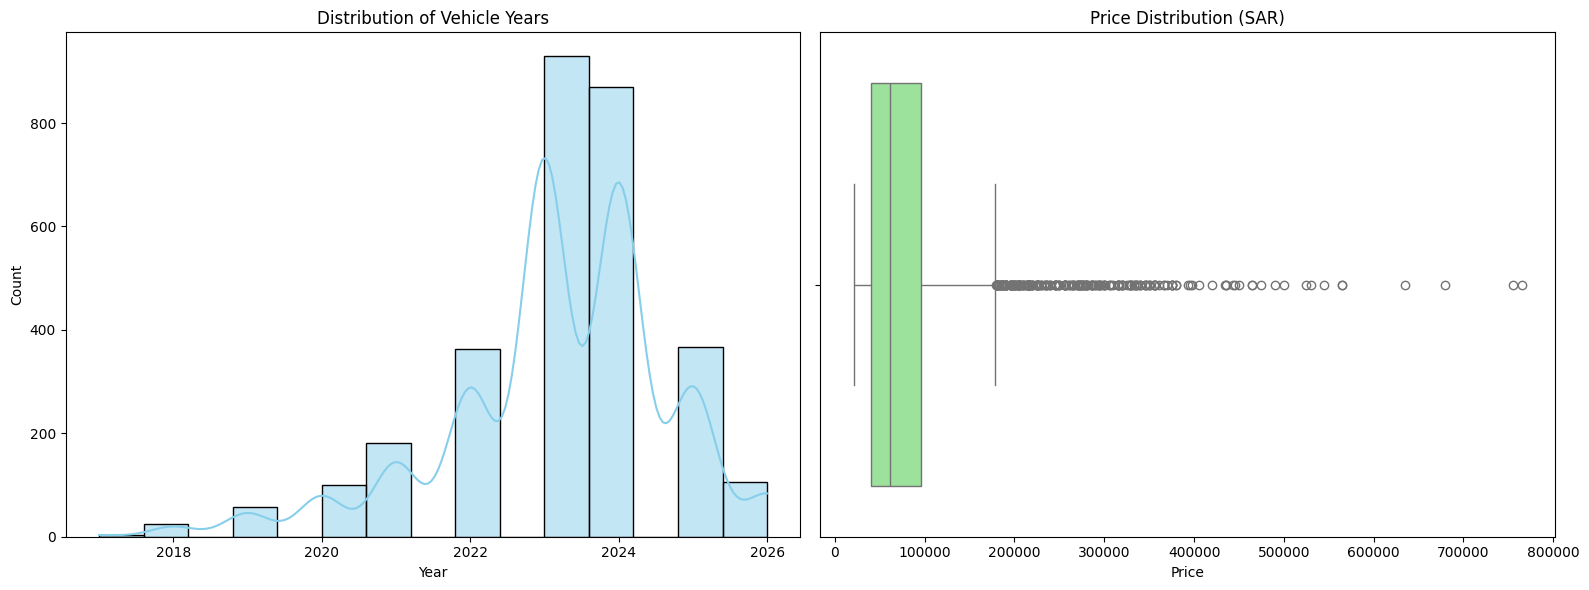


--- Market Composition ---

Top 10 Most Frequent Makes:
make
TOYOTA       668
HYUNDAI      513
KIA          251
NISSAN       205
MAZDA        114
MG            96
GAC           84
SUZUKI        82
GEELY         80
CHEVROLET     77
Name: count, dtype: int64

Sample of fully cleaned records:


,make,model,year,price,mileage
1972,KIA,SELTOS,2023,65000,NaN
2474,TOYOTA,RAV4,2022,89500,NaN
1746,MASERATI,LEVANTE,2022,213000,NaN
2914,TOYOTA,COROLLA,2024,48000,NaN
1153,TOYOTA,FORTUNER,2022,90800,NaN


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data
clean_df = pd.read_csv('syarah_cleaned_data.csv')

print("--- Data Quality Audit ---")
# 1. Missing Value Check
null_summary = clean_df.isnull().sum()
print("\nMissing values per column:")
print(null_summary[null_summary > 0] if null_summary.any() else "No missing values found!")

# 2. Key Column Distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(clean_df['year'], bins=15, kde=True, ax=ax1, color='skyblue')
ax1.set_title('Distribution of Vehicle Years')
ax1.set_xlabel('Year')

sns.boxplot(x=clean_df['price'], ax=ax2, color='lightgreen')
ax2.set_title('Price Distribution (SAR)')
ax2.set_xlabel('Price')

plt.tight_layout()
plt.show()

# 3. Top 10 Makes and Models
print("\n--- Market Composition ---")
top_makes = clean_df['make'].value_counts().head(10)
print("\nTop 10 Most Frequent Makes:")
print(top_makes)

# 4. Consistency Check
print(f"\nSample of fully cleaned records:")
display(clean_df[['make', 'model', 'year', 'price', 'mileage']].sample(min(5, len(clean_df))))

### Why the count differs:
1. **Duplicate Filtering**: The line `df.drop_duplicates(subset=["id"], inplace=True)` in the `save_data` function removes cars that the scraper 'saw' more than once.
2. **Network Events**: Sometimes the browser triggers multiple API responses for the same page content, which increments the 'Captured' log count but doesn't add a new unique car to your final dataset.
3. **Page Overlap**: As cars are sold or added while you are scraping, the website's pagination can shift, causing the same car to appear on Page 4 and then again on Page 5.